In [2]:
# ============================================================================
# BLOC 1 - IMPORTATION DES BIBLIOTHÈQUES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc, ConfusionMatrixDisplay)

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [4]:
import os

# Définir le répertoire de travail
os.chdir("/Users/konearounaromeo/ScoringProjet")

In [6]:
# ============================================================================
# BLOC 2 - CHARGEMENT DES DONNÉES DEPUIS SAS (IMPUTATION PMM)
# ============================================================================

# Chargement des données imputées par PMM
try:
    df = pd.read_csv("donnees_imputees_PMM.csv")
    print("Données chargées : donnees_imputees_PMM.csv")
    print(f"  Observations : {df.shape[0]}")
    print(f"  Variables    : {df.shape[1]}")
except FileNotFoundError:
    print("! Fichier non trouvé. Vérifiez le chemin d'accès.")
    print("  Tentative avec chemin relatif...")
    df = pd.read_csv("../Resultats/donnees_imputees_PMM.csv")
    print(" Données chargées avec chemin relatif")

# Chargement des scores pour validation
try:
    scores = pd.read_csv("scores_PMM.csv",encoding='latin1')
    print(" Scores chargés : scores_PMM.csv")
    scores_disponibles = True
except:
    print("! Fichier scores_PMM.csv non trouvé")
    scores_disponibles = False

print(f"\nTaux de défaut global: {df['BAD'].mean()*100:.2f}%")
print(f"Variables disponibles: {list(df.columns)}")

Données chargées : donnees_imputees_PMM.csv
  Observations : 5960
  Variables    : 22
 Scores chargés : scores_PMM.csv

Taux de défaut global: 19.95%
Variables disponibles: ['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'LTV', 'LTV_CAT', 'LOG_CLAGE', 'LOG_LOAN', 'LOG_MORTDUE', 'LOG_VALUE', 'SQRT_DELINQ', 'SQRT_DEROG', 'SQRT_NINQ']


In [8]:
# ============================================================================
# BLOC 3 - PRÉPARATION DES DONNÉES (SANS IMPUTATION - DÉJÀ FAITE DANS SAS)
# ============================================================================

# Les données sont déjà imputées par PMM dans SAS
# Aucune imputation supplémentaire n'est nécessaire

# Séparation features/cible
target = 'BAD'
# Exclure les colonnes non prédictives et les scores
exclude_cols = ['BAD', 'score', 'score_round', 'risque', 'prob', 'logit', 
                'residual', 'leverage', 'decile', 'LTV_CAT']
# Conserver les flags missing pour analyse
keep_missing = ['miss_DEBTINC', 'miss_YOJ', 'miss_DEROG', 'miss_DELINQ',
                'miss_CLAGE', 'miss_NINQ', 'miss_MORTDUE', 'miss_VALUE']

features = [col for col in df.columns if col not in exclude_cols 
            and not col.startswith('LOG_') 
            and not col.startswith('SQRT_')]

X = df[features].copy()
y = df[target].copy()

print(f"Variables explicatives retenues: {len(features)}")
print(f"  - Variables numériques: {len(X.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"  - Variables catégorielles: {len(X.select_dtypes(include=['object']).columns)}")
print(f"  - Flags missing inclus: {len([c for c in features if 'miss_' in c])}")

# Identification des types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Retirer la cible si présente
if target in numeric_features:
    numeric_features.remove(target)

print(f"\nVariables numériques: {numeric_features}")
print(f"Variables catégorielles: {categorical_features}")

# Division train/test (70/30) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nÉchantillon d'entraînement: {X_train.shape[0]} obs ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Échantillon de test: {X_test.shape[0]} obs ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Taux défaut train: {y_train.mean()*100:.2f}%")
print(f"Taux défaut test: {y_test.mean()*100:.2f}%")


Variables explicatives retenues: 13
  - Variables numériques: 11
  - Variables catégorielles: 2
  - Flags missing inclus: 0

Variables numériques: ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'LTV']
Variables catégorielles: ['REASON', 'JOB']

Échantillon d'entraînement: 4172 obs (70.0%)
Échantillon de test: 1788 obs (30.0%)
Taux défaut train: 19.94%
Taux défaut test: 19.97%


In [12]:
# ============================================================================
# BLOC 4 - PIPELINE DE PRÉTRAITEMENT (SANS IMPUTATION)
# ============================================================================

# PAS D'IMPUTATION - Les données sont déjà parfaites (imputation PMM SAS)
# Uniquement standardisation et one-hot encoding

# Pipeline numérique - seulement standardisation (pas d'imputation)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline catégoriel - seulement one-hot encoding (pas d'imputation)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Preprocessor complet
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Ignorer les autres colonnes
)

# Application du prétraitement
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Prétraitement effectué:")
print("  - Standardisation (moyenne=0, écart-type=1) - variables numériques")
print("  - One-hot encoding (drop first) - variables catégorielles")
print("  - AUCUNE imputation - données déjà parfaites (PMM SAS)")

# Récupération des noms de features après one-hot
feature_names = numeric_features.copy()

for i, cat_feat in enumerate(categorical_features):
    encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    if hasattr(encoder, 'categories_') and len(encoder.categories_) > i:
        categories = encoder.categories_[i][1:]  # drop='first'
        for cat in categories:
            feature_names.append(f"{cat_feat}_{cat}")

print(f"Features finales après encodage: {len(feature_names)}")

Prétraitement effectué:
  - Standardisation (moyenne=0, écart-type=1) - variables numériques
  - One-hot encoding (drop first) - variables catégorielles
  - AUCUNE imputation - données déjà parfaites (PMM SAS)
Features finales après encodage: 19


In [14]:
# Afficher la liste des variables
print("\nListe des variables après prétraitement :")
for var in feature_names:
    print(var)


Liste des variables après prétraitement :
LOAN
MORTDUE
VALUE
YOJ
DEROG
DELINQ
CLAGE
NINQ
CLNO
DEBTINC
LTV
REASON_HomeImp
REASON_Unknown
JOB_Office
JOB_Other
JOB_ProfEx
JOB_Sales
JOB_Self
JOB_Unknow


In [16]:
# ============================================================================
# BLOC 5 - GESTION DU DÉSÉQUILIBRE (SMOTE)
# ============================================================================

print(f"Distribution avant SMOTE:")
print(f"  - Classe 0 (bons): {np.bincount(y_train)[0]}")
print(f"  - Classe 1 (défauts): {np.bincount(y_train)[1]}")
print(f"  - Ratio: 1:{np.bincount(y_train)[0]/np.bincount(y_train)[1]:.1f}")

# Application de SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print(f"\nDistribution après SMOTE:")
print(f"  - Classe 0 (bons): {np.bincount(y_train_res)[0]}")
print(f"  - Classe 1 (défauts): {np.bincount(y_train_res)[1]}")
print(f"  - Ratio: 1:1 (équilibré)")
print("Échantillonnage synthétique (SMOTE) effectué")


Distribution avant SMOTE:
  - Classe 0 (bons): 3340
  - Classe 1 (défauts): 832
  - Ratio: 1:4.0

Distribution après SMOTE:
  - Classe 0 (bons): 3340
  - Classe 1 (défauts): 3340
  - Ratio: 1:1 (équilibré)
Échantillonnage synthétique (SMOTE) effectué


In [22]:
# ============================================================================
# BLOC 6 - DICTIONNAIRE DES MODÈLES (SELON VOTRE SÉLECTION)
# ============================================================================
models = {
    'Régression Logistique': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced',
        C=1.0
    ),
    
    'Arbre de Décision': DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=25,
        class_weight='balanced'
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
}

print(f"{len(models)} modèles initialisés")

4 modèles initialisés


In [24]:
# ============================================================================
# BLOC 7 - ENTRAÎNEMENT ET ÉVALUATION
# ============================================================================
results = {}
cv_scores = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionnaires pour stocker les métriques sur train et test
train_metrics = {}
test_metrics = {}

for name, model in models.items():
    print(f"\n {name}")
    print("-" * 40)
    
    # Entraînement
    model.fit(X_train_res, y_train_res)
    
    # Prédictions sur train
    y_train_pred = model.predict(X_train_processed)
    y_train_proba = model.predict_proba(X_train_processed)[:, 1]
    
    # Prédictions sur test
    y_test_pred = model.predict(X_test_processed)
    y_test_proba = model.predict_proba(X_test_processed)[:, 1]
    
    # Métriques sur train
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_proba)
    
    # Métriques sur test
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    # Validation croisée (5-fold)
    cv_scores_model = cross_val_score(
        model, X_train_res, y_train_res, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1
    )
    
    # Stockage des métriques
    train_metrics[name] = {
        'accuracy': train_accuracy,
        'precision': train_precision,
        'recall': train_recall,
        'f1': train_f1,
        'auc': train_auc,
        'confusion_matrix': confusion_matrix(y_train, y_train_pred)
    }
    
    test_metrics[name] = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'auc': test_auc,
        'confusion_matrix': confusion_matrix(y_test, y_test_pred),
        'y_pred': y_test_pred,
        'y_proba': y_test_proba
    }
    
    results[name] = {
        'model': model,
        'y_pred': y_test_pred,
        'y_proba': y_test_proba,
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'auc_roc': test_auc,
        'cv_mean': cv_scores_model.mean(),
        'cv_std': cv_scores_model.std(),
        'confusion_matrix': confusion_matrix(y_test, y_test_pred)
    }
    
    # Affichage comparatif train/test
    print(f"  TRAIN:")
    print(f"    Accuracy:  {train_accuracy:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1: {train_f1:.4f} | AUC: {train_auc:.4f}")
    print(f"  TEST:")
    print(f"    Accuracy:  {test_accuracy:.4f} | Precision: {test_precision:.4f} | Recall: {test_recall:.4f} | F1: {test_f1:.4f} | AUC: {test_auc:.4f}")
    print(f"  CV (F1):   {cv_scores_model.mean():.4f} (±{cv_scores_model.std():.4f})")


 Régression Logistique
----------------------------------------
  TRAIN:
    Accuracy:  0.7522 | Precision: 0.4260 | Recall: 0.6983 | F1: 0.5291 | AUC: 0.8023
  TEST:
    Accuracy:  0.7321 | Precision: 0.3934 | Recall: 0.6303 | F1: 0.4844 | AUC: 0.7671
  CV (F1):   0.7207 (±0.0093)

 Arbre de Décision
----------------------------------------
  TRAIN:
    Accuracy:  0.7874 | Precision: 0.4723 | Recall: 0.5625 | F1: 0.5134 | AUC: 0.7819
  TEST:
    Accuracy:  0.7713 | Precision: 0.4381 | Recall: 0.5154 | F1: 0.4736 | AUC: 0.7400
  CV (F1):   0.7726 (±0.0117)

 Gradient Boosting
----------------------------------------
  TRAIN:
    Accuracy:  0.8746 | Precision: 0.6803 | Recall: 0.7007 | F1: 0.6903 | AUC: 0.9087
  TEST:
    Accuracy:  0.8378 | Precision: 0.5933 | Recall: 0.5966 | F1: 0.5950 | AUC: 0.8334
  CV (F1):   0.8686 (±0.0099)

 XGBoost
----------------------------------------
  TRAIN:
    Accuracy:  0.8672 | Precision: 0.6635 | Recall: 0.6779 | F1: 0.6706 | AUC: 0.8987
  TEST:
  

In [64]:
from docx import Document

# Création du document Word
document = Document()
document.add_heading("Résultats des modèles - Train et Test", level=1)

for name in models.keys():
    document.add_heading(name, level=2)

    # --- Métriques train/test ---
    table_metrics = document.add_table(rows=3, cols=7)
    table_metrics.style = "Table Grid"
    
    # En-têtes
    headers = ["Dataset", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "CV F1"]
    for i, h in enumerate(headers):
        table_metrics.rows[0].cells[i].text = h

    # Train
    train = train_metrics[name]
    train_cells = table_metrics.rows[1].cells
    train_cells[0].text = "TRAIN"
    train_cells[1].text = f"{train['accuracy']:.4f}"
    train_cells[2].text = f"{train['precision']:.4f}"
    train_cells[3].text = f"{train['recall']:.4f}"
    train_cells[4].text = f"{train['f1']:.4f}"
    train_cells[5].text = f"{train['auc']:.4f}"
    train_cells[6].text = "-"  # Pas de CV pour train

    # Test
    test = test_metrics[name]
    test_cells = table_metrics.rows[2].cells
    test_cells[0].text = "TEST"
    test_cells[1].text = f"{test['accuracy']:.4f}"
    test_cells[2].text = f"{test['precision']:.4f}"
    test_cells[3].text = f"{test['recall']:.4f}"
    test_cells[4].text = f"{test['f1']:.4f}"
    test_cells[5].text = f"{test['auc']:.4f}"
    test_cells[6].text = f"{results[name]['cv_mean']:.4f} (±{results[name]['cv_std']:.4f})"

    document.add_paragraph("")  # Ligne vide

    # --- Matrice de confusion test ---
    cm = test['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    document.add_paragraph("Matrice de confusion (TEST) :")
    table_cm = document.add_table(rows=3, cols=3)
    table_cm.style = "Table Grid"

    # En-têtes
    table_cm.cell(0, 0).text = ""
    table_cm.cell(0, 1).text = "Prédit NON"
    table_cm.cell(0, 2).text = "Prédit OUI"
    table_cm.cell(1, 0).text = "Réel NON (0)"
    table_cm.cell(1, 1).text = str(tn)
    table_cm.cell(1, 2).text = str(fp)
    table_cm.cell(2, 0).text = "Réel OUI (1)"
    table_cm.cell(2, 1).text = str(fn)
    table_cm.cell(2, 2).text = str(tp)

    document.add_paragraph("")  # Ligne vide

# Sauvegarde
file_name = "resultats_modeles.docx"
document.save(file_name)
print(f" Export terminé : {file_name}")


 Export terminé : resultats_modeles.docx



 Régression Logistique - Matrices de confusion (Train vs Test)
------------------------------------------------------------
  Matrice sauvegardée: matrice_confusion_Régression_Logistique.png


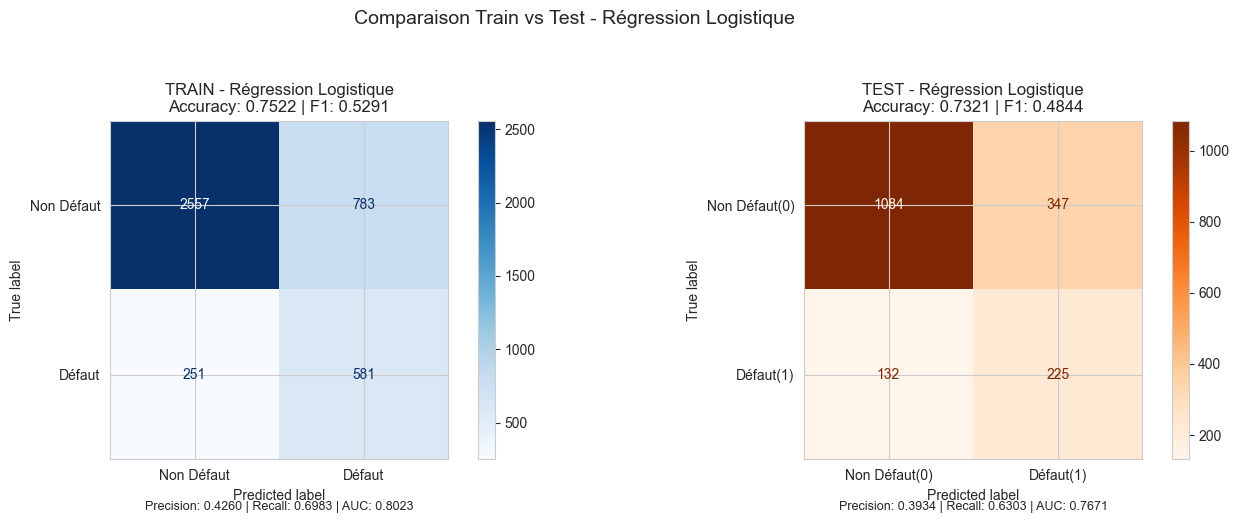


  TRAIN - Matrice de confusion:
                           Prédit NON   Prédit OUI
    Réel NON (0)                 2557          783
    Réel OUI (1)                  251          581
     Recall: 0.6983 | Précision: 0.4260

  TEST - Matrice de confusion:
                         Prédit NON(0) Prédit OUI(1)
    Réel NON (0)                 1084          347
    Réel OUI (1)                  132          225
     Recall: 0.6303 | Précision: 0.3934

 Arbre de Décision - Matrices de confusion (Train vs Test)
------------------------------------------------------------
  Matrice sauvegardée: matrice_confusion_Arbre_de_Décision.png


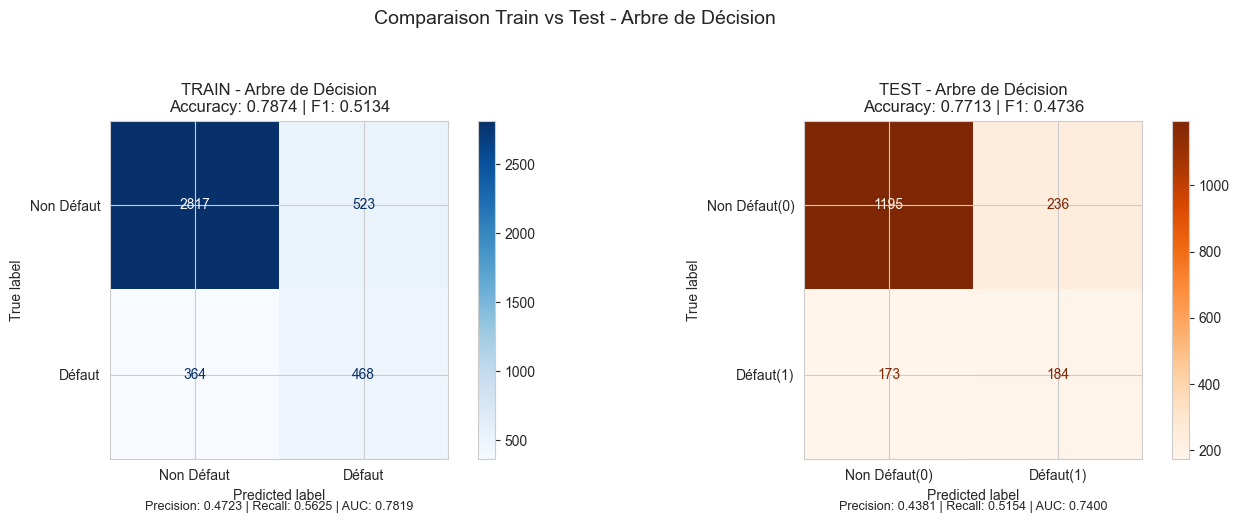


  TRAIN - Matrice de confusion:
                           Prédit NON   Prédit OUI
    Réel NON (0)                 2817          523
    Réel OUI (1)                  364          468
     Recall: 0.5625 | Précision: 0.4723

  TEST - Matrice de confusion:
                         Prédit NON(0) Prédit OUI(1)
    Réel NON (0)                 1195          236
    Réel OUI (1)                  173          184
     Recall: 0.5154 | Précision: 0.4381

 Gradient Boosting - Matrices de confusion (Train vs Test)
------------------------------------------------------------
  Matrice sauvegardée: matrice_confusion_Gradient_Boosting.png


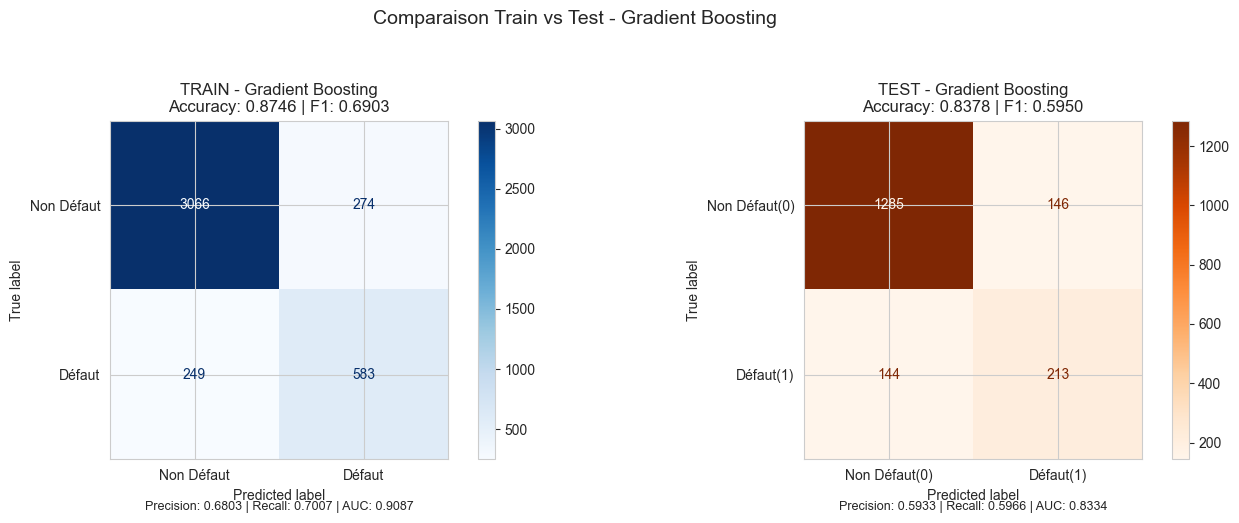


  TRAIN - Matrice de confusion:
                           Prédit NON   Prédit OUI
    Réel NON (0)                 3066          274
    Réel OUI (1)                  249          583
     Recall: 0.7007 | Précision: 0.6803

  TEST - Matrice de confusion:
                         Prédit NON(0) Prédit OUI(1)
    Réel NON (0)                 1285          146
    Réel OUI (1)                  144          213
     Recall: 0.5966 | Précision: 0.5933

 XGBoost - Matrices de confusion (Train vs Test)
------------------------------------------------------------
  Matrice sauvegardée: matrice_confusion_XGBoost.png


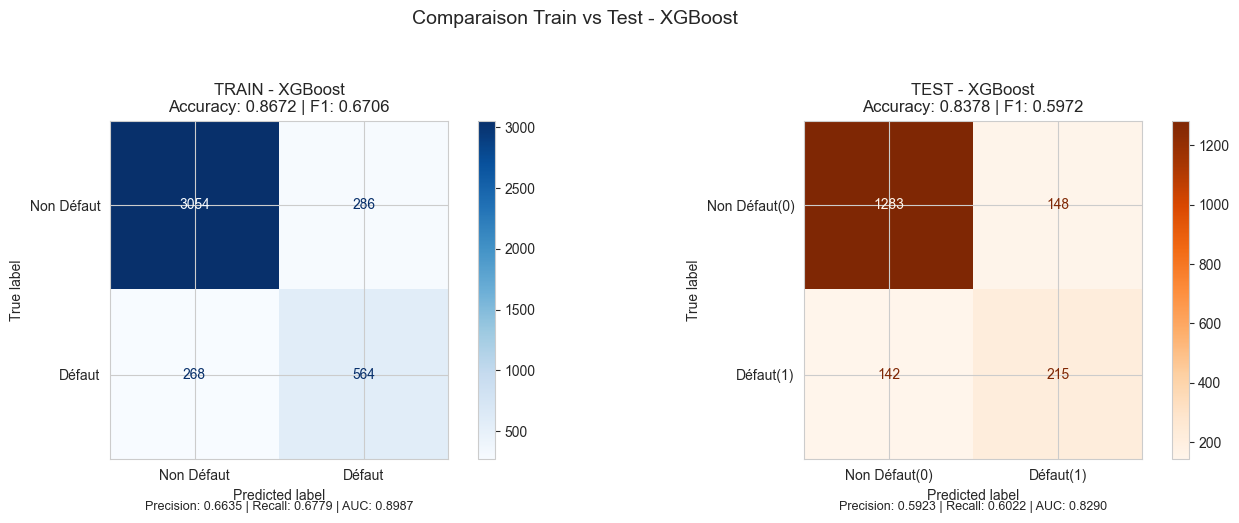


  TRAIN - Matrice de confusion:
                           Prédit NON   Prédit OUI
    Réel NON (0)                 3054          286
    Réel OUI (1)                  268          564
     Recall: 0.6779 | Précision: 0.6635

  TEST - Matrice de confusion:
                         Prédit NON(0) Prédit OUI(1)
    Réel NON (0)                 1283          148
    Réel OUI (1)                  142          215
     Recall: 0.6022 | Précision: 0.5923


In [30]:
# ============================================================================
# BLOC 8 - AFFICHAGE DES MATRICES DE CONFUSION (CÔTE À CÔTE POUR CHAQUE MODÈLE)
# ============================================================================

# Configuration pour l'affichage dans la console
plt.ion()  # Mode interactif

for name in models.keys():
    print(f"\n {name} - Matrices de confusion (Train vs Test)")
    print("-" * 60)
    
    # Création d'une figure avec deux sous-plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Matrice de confusion sur TRAIN
    cm_train = train_metrics[name]['confusion_matrix']
    tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
    
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Non Défaut', 'Défaut'])
    disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'TRAIN - {name}\nAccuracy: {train_metrics[name]["accuracy"]:.4f} | F1: {train_metrics[name]["f1"]:.4f}')
    
    # Ajout des métriques sur la matrice train
    axes[0].text(0.5, -0.15, 
                 f'Precision: {train_metrics[name]["precision"]:.4f} | Recall: {train_metrics[name]["recall"]:.4f} | AUC: {train_metrics[name]["auc"]:.4f}',
                 transform=axes[0].transAxes, ha='center', fontsize=9)
    
    # Matrice de confusion sur TEST
    cm_test = test_metrics[name]['confusion_matrix']
    tn_test, fp_test, fn_test, tp_test = cm_test.ravel()
    
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Non Défaut(0)', 'Défaut(1)'])
    disp_test.plot(ax=axes[1], cmap='Oranges', values_format='d')
    axes[1].set_title(f'TEST - {name}\nAccuracy: {test_metrics[name]["accuracy"]:.4f} | F1: {test_metrics[name]["f1"]:.4f}')
    
    # Ajout des métriques sur la matrice test
    axes[1].text(0.5, -0.15, 
                 f'Precision: {test_metrics[name]["precision"]:.4f} | Recall: {test_metrics[name]["recall"]:.4f} | AUC: {test_metrics[name]["auc"]:.4f}',
                 transform=axes[1].transAxes, ha='center', fontsize=9)
    
    plt.suptitle(f'Comparaison Train vs Test - {name}', fontsize=14, y=1.05)
    plt.tight_layout()
    
    # Sauvegarde
    plt.savefig(f'matrice_confusion_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    print(f"  Matrice sauvegardée: matrice_confusion_{name.replace(' ', '_')}.png")
    # Affichage dans la console
    plt.show(block=False)
    plt.pause(1)  # Pause pour permettre l'affichage
    
    # Affichage textuel dans la console
    print(f"\n  TRAIN - Matrice de confusion:")
    print(f"    {'':20} {'Prédit NON':>12} {'Prédit OUI':>12}")
    print(f"    {'Réel NON (0)':20} {tn_train:12} {fp_train:12}")
    print(f"    {'Réel OUI (1)':20} {fn_train:12} {tp_train:12}")
    print(f"     Recall: {train_metrics[name]['recall']:.4f} | Précision: {train_metrics[name]['precision']:.4f}")
    
    print(f"\n  TEST - Matrice de confusion:")
    print(f"    {'':20} {'Prédit NON(0)':>12} {'Prédit OUI(1)':>12}")
    print(f"    {'Réel NON (0)':20} {tn_test:12} {fp_test:12}")
    print(f"    {'Réel OUI (1)':20} {fn_test:12} {tp_test:12}")
    print(f"     Recall: {test_metrics[name]['recall']:.4f} | Précision: {test_metrics[name]['precision']:.4f}")


 Arbre de décision sauvegardé: arbre_decision_complet.png


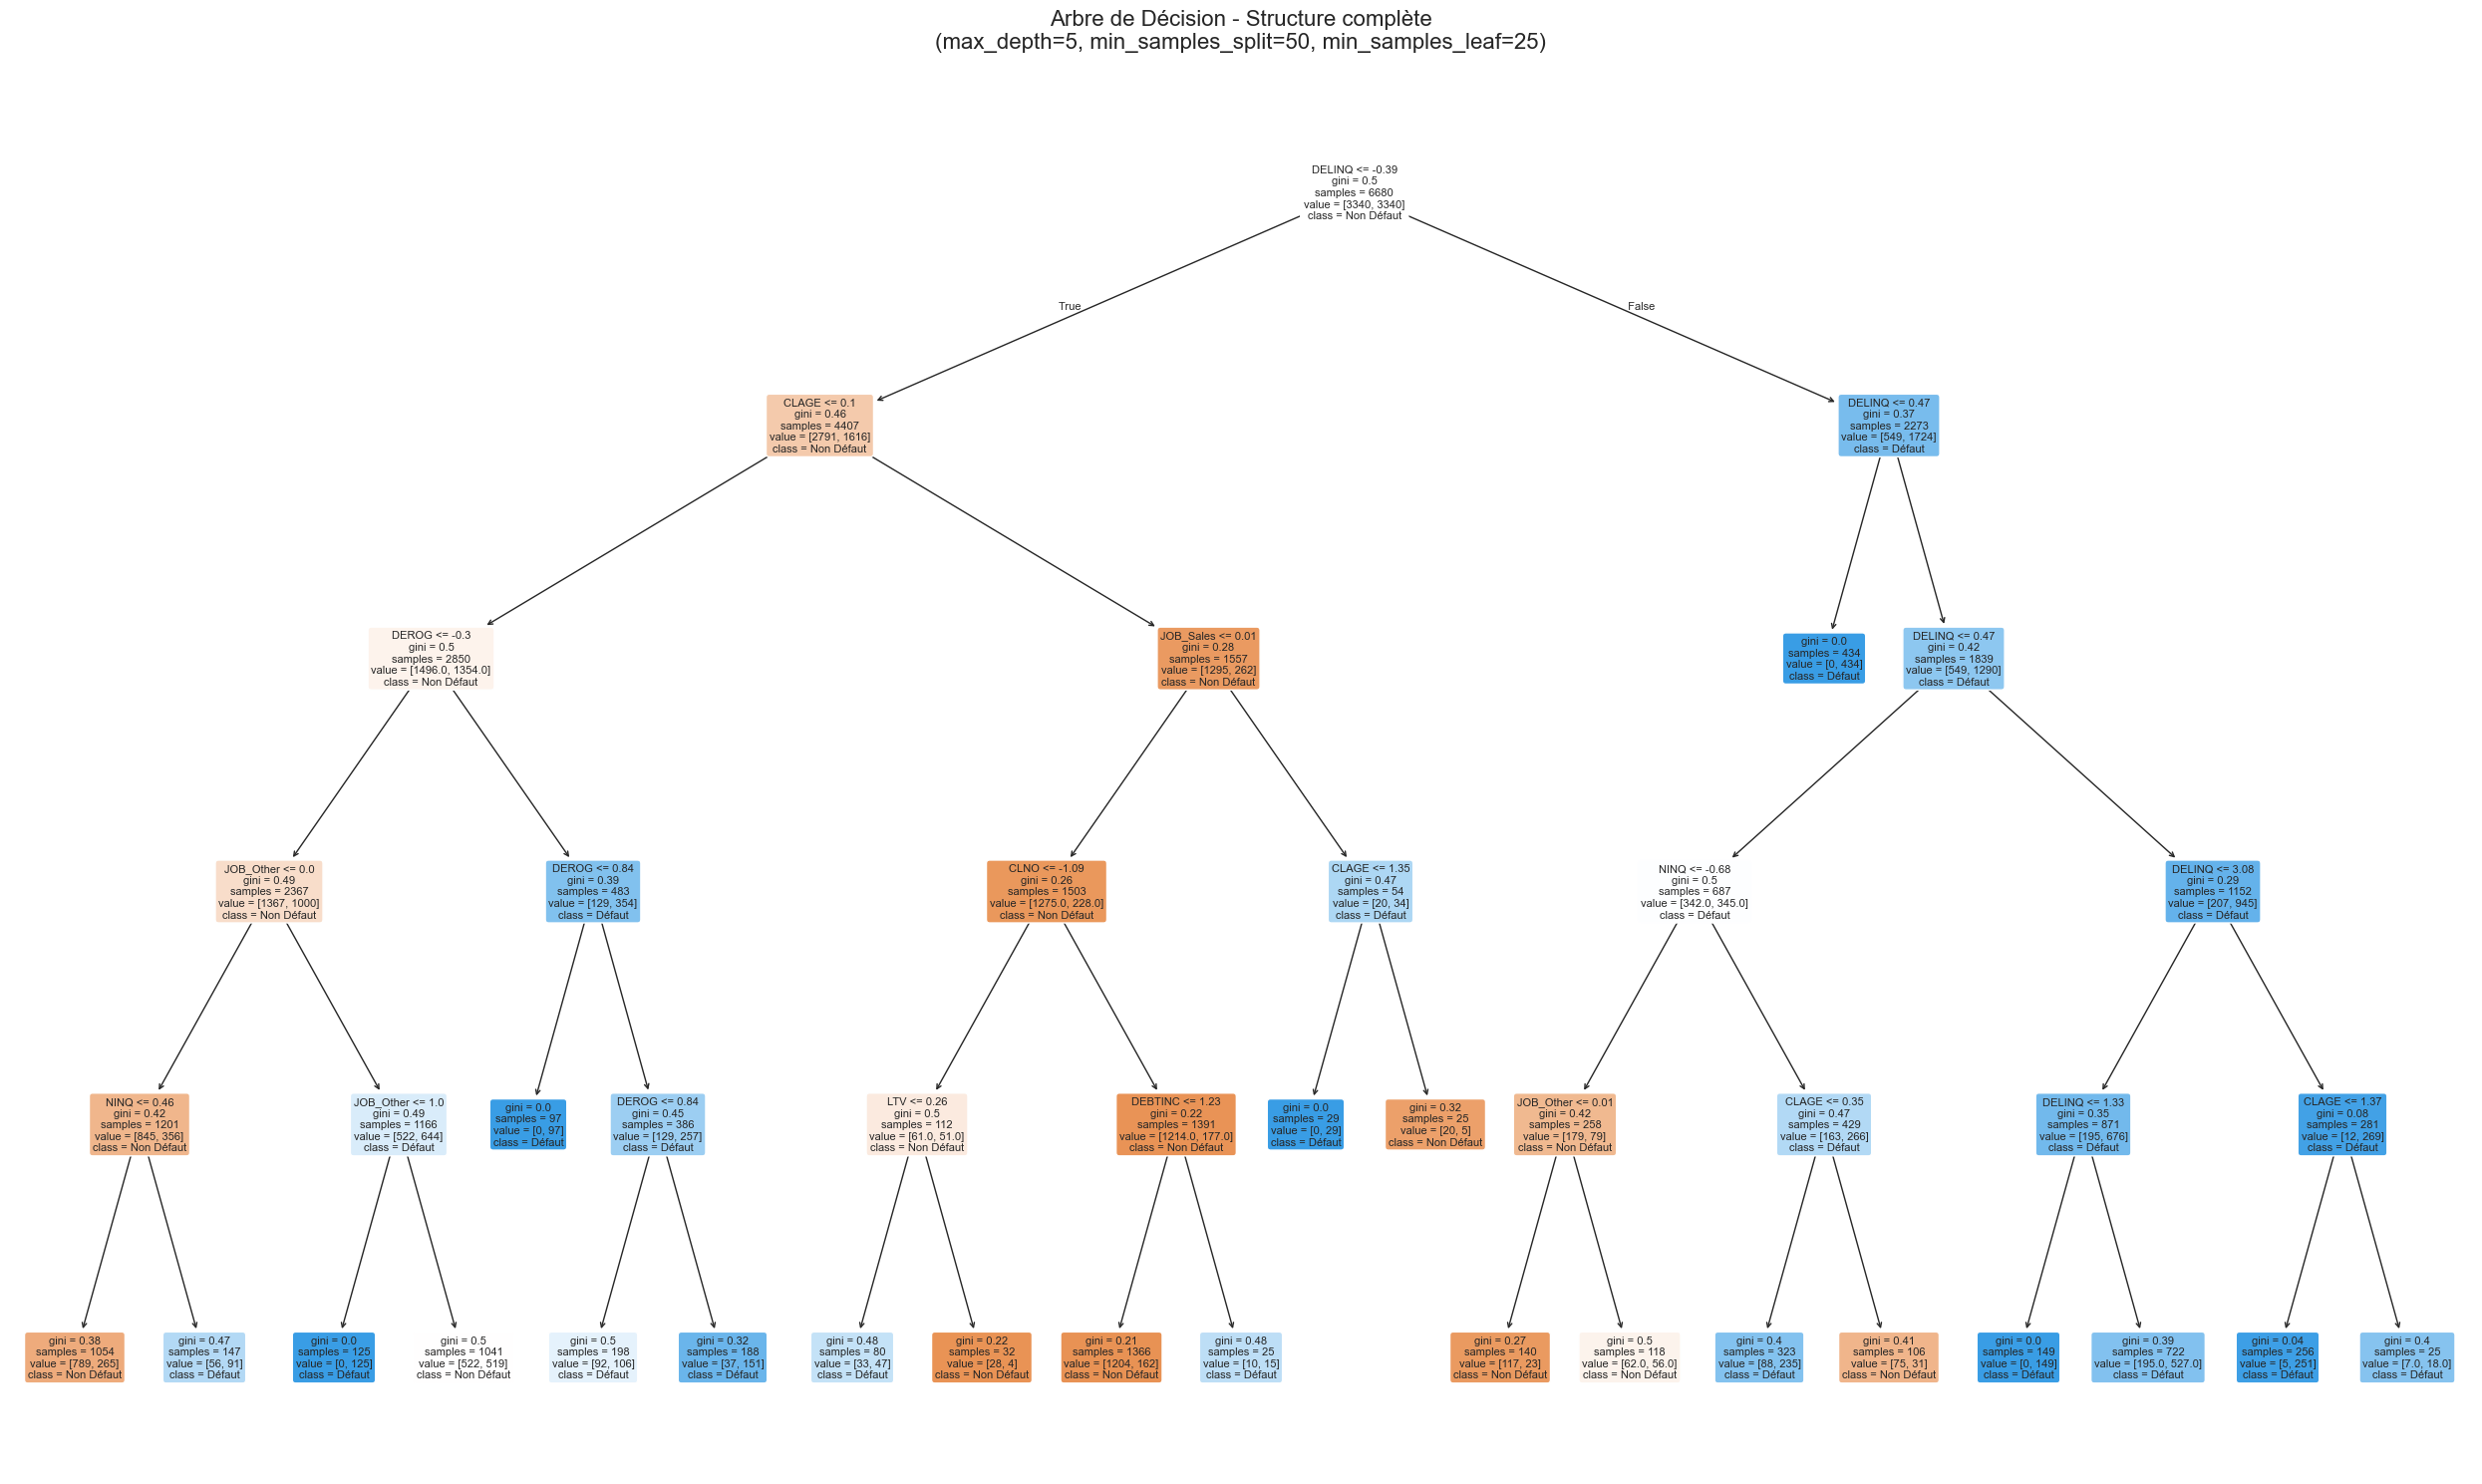


  Statistiques de l'arbre:
    • Profondeur: 5
    • Nombre de feuilles: 22
    • Nombre de noeuds: 43

  Répartition des classes par noeud:
    • Noeuds internes: 21
    • Noeuds feuilles: 22
      Feuille 5: 1054 échantillons, impureté: 0.3764, distribution: [0, 0]
      Feuille 6: 147 échantillons, impureté: 0.4717, distribution: [0, 0]
      Feuille 8: 125 échantillons, impureté: 0.0000, distribution: [0, 1]
      Feuille 9: 1041 échantillons, impureté: 0.5000, distribution: [0, 0]
      Feuille 11: 97 échantillons, impureté: 0.0000, distribution: [0, 1]
      Feuille 13: 198 échantillons, impureté: 0.4975, distribution: [0, 0]
      Feuille 14: 188 échantillons, impureté: 0.3161, distribution: [0, 0]
      Feuille 18: 80 échantillons, impureté: 0.4847, distribution: [0, 0]
      Feuille 19: 32 échantillons, impureté: 0.2188, distribution: [0, 0]
      Feuille 21: 1366 échantillons, impureté: 0.2091, distribution: [0, 0]
      Feuille 22: 25 échantillons, impureté: 0.4800, distrib

In [36]:
# ============================================================================
# BLOC 9 - VISUALISATION DE L'ARBRE DE DÉCISION
# ============================================================================

if 'Arbre de Décision' in models:
    tree_model = models['Arbre de Décision']
    
    # Création d'une grande figure pour l'arbre
    plt.figure(figsize=(25, 15))
    
    # Plot de l'arbre
    plot_tree(tree_model, 
              feature_names=feature_names,
              class_names=['Non Défaut', 'Défaut'],
              filled=True,
              rounded=True,
              fontsize=8,
              max_depth=5,  # Afficher toute la profondeur
              precision=2)
    
    plt.title('Arbre de Décision - Structure complète\n(max_depth=5, min_samples_split=50, min_samples_leaf=25)', 
              fontsize=16, pad=20)
    
    plt.tight_layout()
    # Sauvegarde en haute résolution
    plt.savefig('arbre_decision_complet.png', dpi=300, bbox_inches='tight')
    print(" Arbre de décision sauvegardé: arbre_decision_complet.png")
    plt.show(block=False)
    plt.pause(1)
    
    # Statistiques de l'arbre
    print(f"\n  Statistiques de l'arbre:")
    print(f"    • Profondeur: {tree_model.get_depth()}")
    print(f"    • Nombre de feuilles: {tree_model.get_n_leaves()}")
    print(f"    • Nombre de noeuds: {tree_model.tree_.node_count}")
    
    # Analyse des noeuds
    print(f"\n  Répartition des classes par noeud:")
    n_nodes = tree_model.tree_.node_count
    children_left = tree_model.tree_.children_left
    children_right = tree_model.tree_.children_right
    feature = tree_model.tree_.feature
    threshold = tree_model.tree_.threshold
    values = tree_model.tree_.value
    
    # Trouver les noeuds feuilles
    leaf_nodes = []
    for i in range(n_nodes):
        if children_left[i] == -1 and children_right[i] == -1:
            leaf_nodes.append(i)
    
    print(f"    • Noeuds internes: {n_nodes - len(leaf_nodes)}")
    print(f"    • Noeuds feuilles: {len(leaf_nodes)}")
    
    # Distribution dans les feuilles
    leaf_samples = []
    leaf_purities = []
    for leaf in leaf_nodes:
        samples = tree_model.tree_.n_node_samples[leaf]
        impurity = tree_model.tree_.impurity[leaf]
        leaf_samples.append(samples)
        leaf_purities.append(impurity)
        class_dist = values[leaf][0]
        print(f"      Feuille {leaf}: {samples} échantillons, "
              f"impureté: {impurity:.4f}, "
              f"distribution: [{int(class_dist[0])}, {int(class_dist[1])}]")
    
    print(f"\n     Taille moyenne des feuilles: {np.mean(leaf_samples):.1f}")

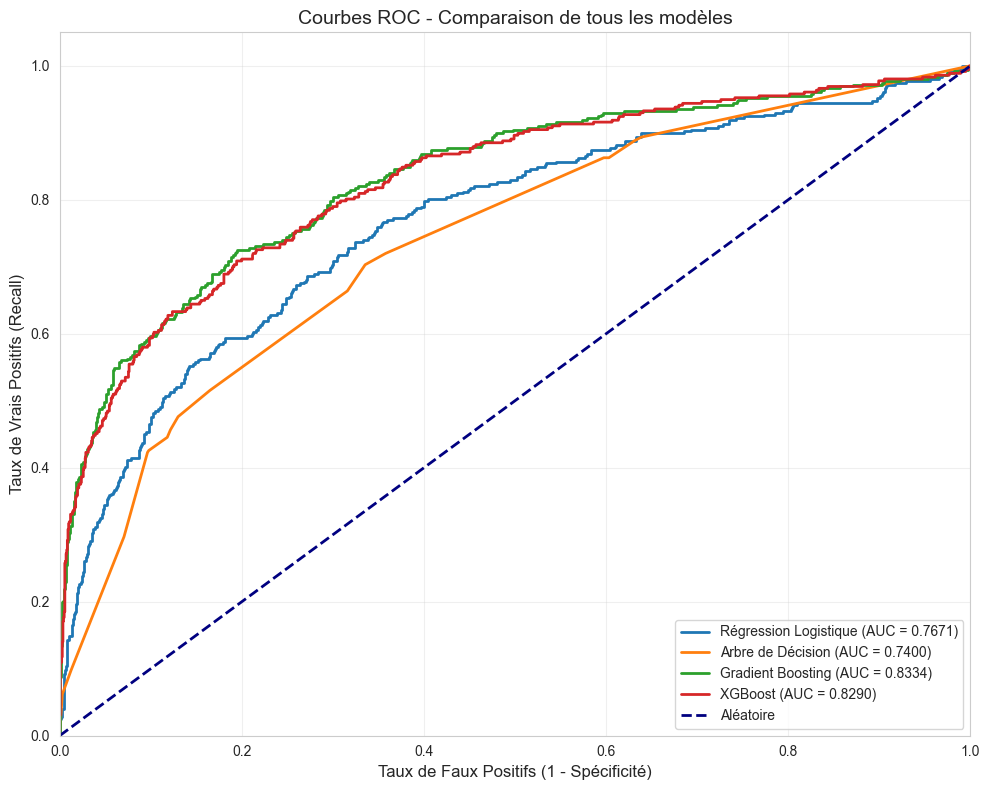

 Courbes ROC sauvegardées: courbes_roc_tous_modeles.png


In [38]:
# ============================================================================
# BLOC 10 - COURBES ROC POUR TOUS LES MODÈLES
# ============================================================================

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Recall)', fontsize=12)
plt.title('Courbes ROC - Comparaison de tous les modèles', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('courbes_roc_tous_modeles.png', dpi=150, bbox_inches='tight')
plt.show(block=False)
plt.pause(1)

print(" Courbes ROC sauvegardées: courbes_roc_tous_modeles.png")



 Régression Logistique - TOP 5 coefficients (valeur absolue):
------------------------------------------------------------
   1. JOB_Unknow                          - 1.6976
   2. JOB_Sales                           + 1.2982
   3. DELINQ                              + 0.8187
   4. JOB_Office                          - 0.7680
   5. JOB_Self                            + 0.6399

 Arbre de Décision - TOP 5 variables importantes:
------------------------------------------------------------
   1. DELINQ                              0.5054
   2. CLAGE                               0.1890
   3. JOB_Other                           0.1149
   4. DEROG                               0.0854
   5. NINQ                                0.0524
   6. JOB_Sales                           0.0187
   7. CLNO                                0.0176
   8. DEBTINC                             0.0090
   9. LTV                                 0.0077
  10. JOB_Office                          0.0000

 Gradient Boosting

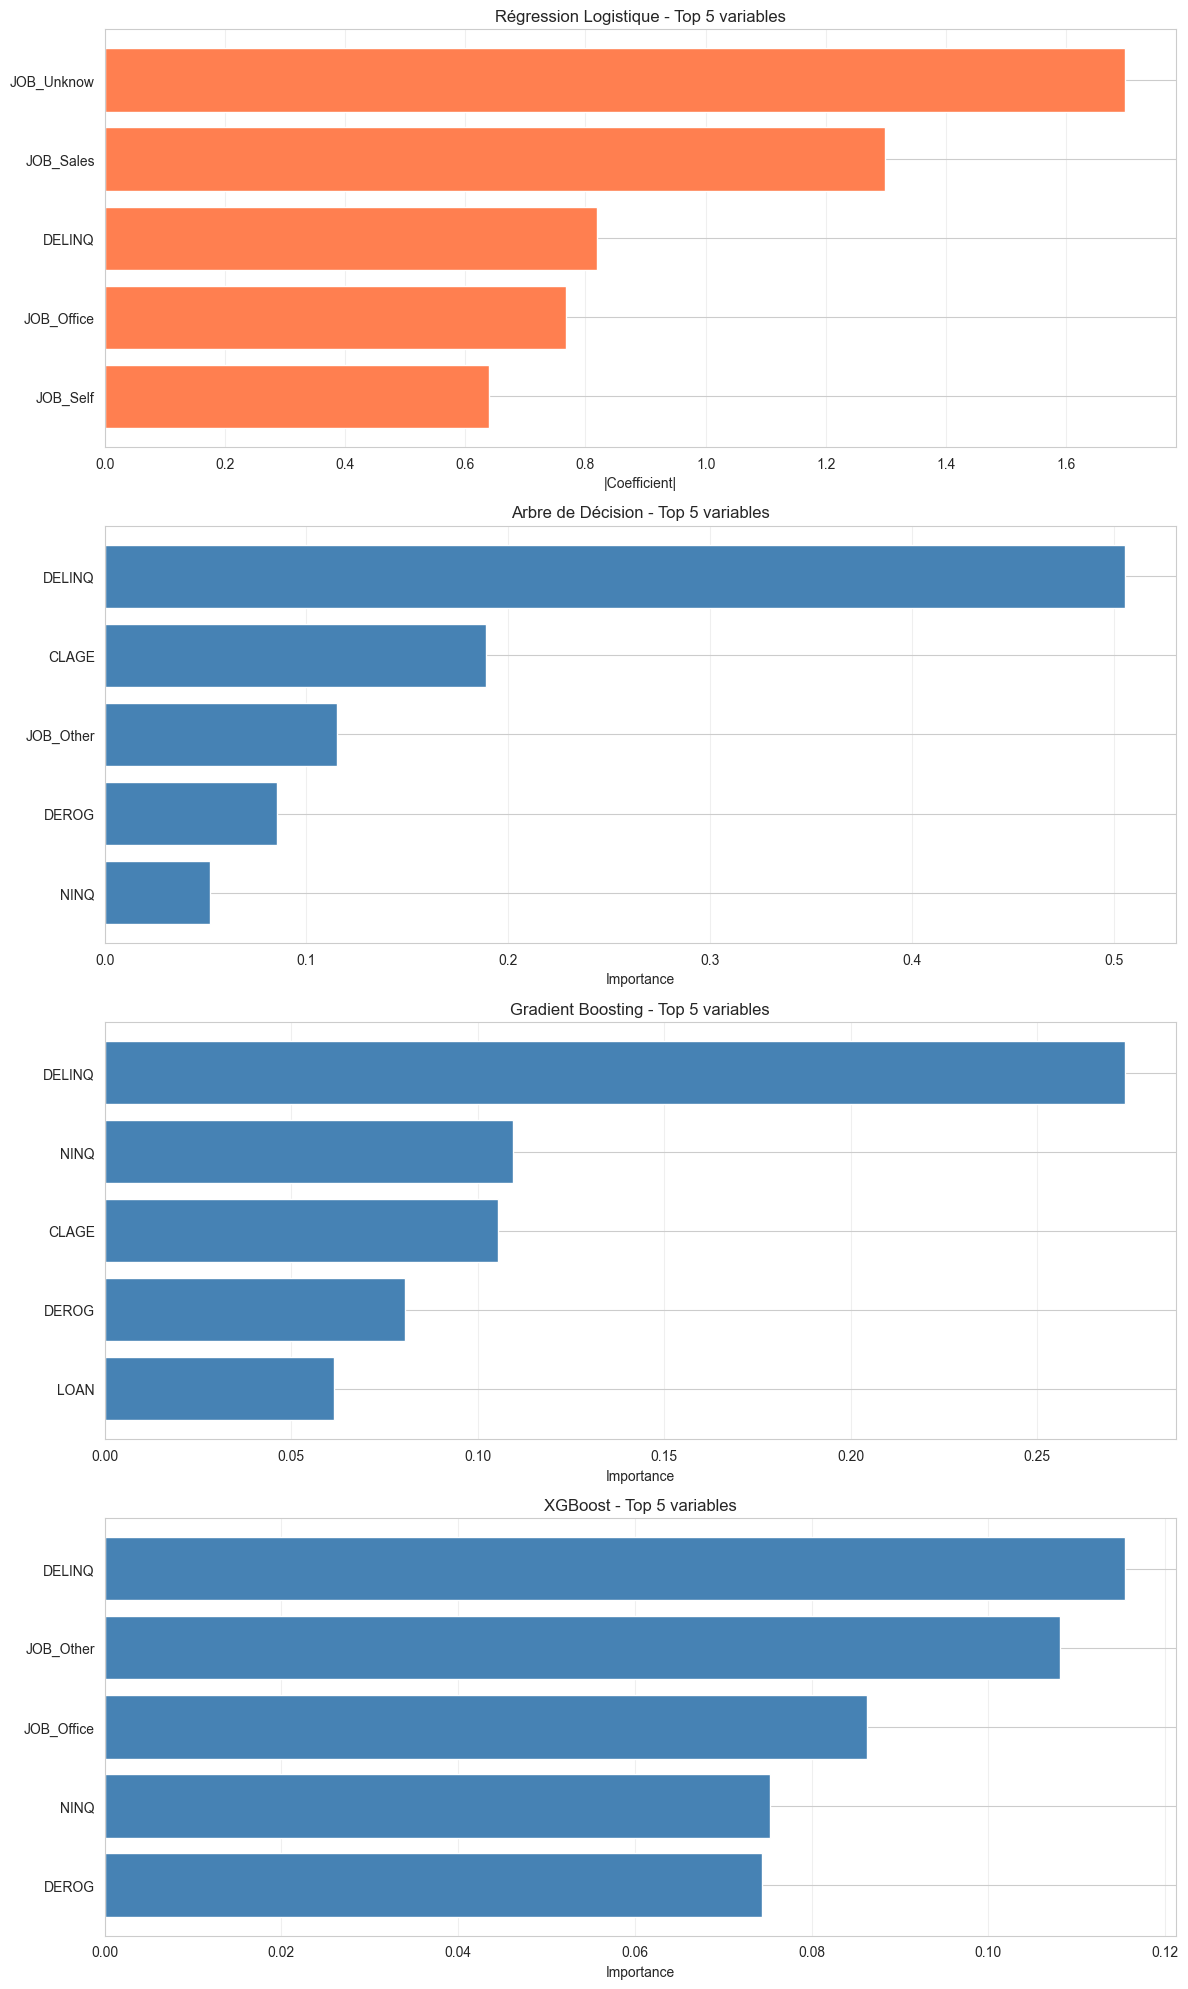


 Graphique des importances sauvegardé: importances_variables_tous_modeles.png


In [42]:
# ============================================================================
# BLOC 11 - IMPORTANCE DES VARIABLES POUR TOUS LES MODÈLES
# ============================================================================

# Dictionnaire pour stocker les importances
importances_dict = {}

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
        # Alignement des noms de features
        if len(feature_names) != len(importances):
            print(f" {name}: {len(feature_names)} features vs {len(importances)} importances")
            min_len = min(len(feature_names), len(importances))
            feature_names_aligned = feature_names[:min_len]
            importances_aligned = importances[:min_len]
        else:
            feature_names_aligned = feature_names
            importances_aligned = importances
        
        # Création du DataFrame
        imp_df = pd.DataFrame({
            'Variable': feature_names_aligned,
            'Importance': importances_aligned
        }).sort_values('Importance', ascending=False).reset_index(drop=True)
        
        importances_dict[name] = imp_df
        
        # Affichage du TOP 10
        print(f"\n {name} - TOP 5 variables importantes:")
        print("-" * 60)
        for i, row in imp_df.head(10).iterrows():
            print(f"  {i+1:2d}. {row['Variable']:<35} {row['Importance']:.4f}")
            
    elif hasattr(model, 'coef_'):
        # Pour la régression logistique
        coefs = model.coef_[0]
        if len(feature_names) != len(coefs):
            min_len = min(len(feature_names), len(coefs))
            feature_names_aligned = feature_names[:min_len]
            coefs_aligned = coefs[:min_len]
        else:
            feature_names_aligned = feature_names
            coefs_aligned = coefs
        
        imp_df = pd.DataFrame({
            'Variable': feature_names_aligned,
            'Coefficient': coefs_aligned,
            '|Coefficient|': np.abs(coefs_aligned)
        }).sort_values('|Coefficient|', ascending=False).reset_index(drop=True)
        
        importances_dict[name] = imp_df
        
        print(f"\n {name} - TOP 5 coefficients (valeur absolue):")
        print("-" * 60)
        for i, row in imp_df.head(5).iterrows():
            sign = "+" if row['Coefficient'] > 0 else "-"
            print(f"  {i+1:2d}. {row['Variable']:<35} {sign} {abs(row['Coefficient']):.4f}")

# Visualisation comparative des importances
n_models = len([m for m in models.keys() if m in importances_dict])
if n_models > 0:
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 5*n_models))
    if n_models == 1:
        axes = [axes]
    
    for idx, (name, imp_df) in enumerate(importances_dict.items()):
        top5 = imp_df.head(5).sort_values('Importance' if 'Importance' in imp_df.columns else '|Coefficient|', ascending=True)
        
        if 'Importance' in imp_df.columns:
            axes[idx].barh(top5['Variable'], top5['Importance'], color='steelblue')
            axes[idx].set_xlabel('Importance')
        else:
            axes[idx].barh(top5['Variable'], top5['|Coefficient|'], color='coral')
            axes[idx].set_xlabel('|Coefficient|')
        
        axes[idx].set_title(f'{name} - Top 5 variables')
        axes[idx].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('importances_variables_tous_modeles.png', dpi=150, bbox_inches='tight')
    plt.show(block=False)
    plt.pause(1)
    print("\n Graphique des importances sauvegardé: importances_variables_tous_modeles.png")


In [44]:
# ============================================================================
# BLOC 12 - COMPARAISON DES PERFORMANCES
# ============================================================================

# DataFrame des résultats
results_df = pd.DataFrame([
    {
        'Modèle': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1_score'],
        'AUC-ROC': res['auc_roc'],
        'CV_F1': res['cv_mean']
    }
    for name, res in results.items()
])

# TRI PAR AUC PUIS RECALL
results_df = results_df.sort_values(
    by=['AUC-ROC', 'Recall'],
    ascending=[False, False]
).reset_index(drop=True)

print("\n CLASSEMENT DES MODÈLES PAR AUC-ROC PUIS RECALL:")
print("-" * 80)
print(results_df[['Modèle', 'AUC-ROC', 'Recall', 'F1-Score']].round(4).to_string(index=False))

# Meilleur modèle selon AUC puis Recall
best_model_name = results_df.iloc[0]['Modèle']
best_model = results[best_model_name]['model']
best_metrics = results[best_model_name]

print(f"\n MEILLEUR MODÈLE (selon AUC puis Recall): {best_model_name}")
print(f"  AUC-ROC:  {best_metrics['auc_roc']:.4f}")
print(f"  Recall:   {best_metrics['recall']:.4f}")
print(f"  F1-Score: {best_metrics['f1_score']:.4f}")
print(f"  CV (F1):  {best_metrics['cv_mean']:.4f} (±{best_metrics['cv_std']:.4f})")



 CLASSEMENT DES MODÈLES PAR AUC-ROC PUIS RECALL:
--------------------------------------------------------------------------------
               Modèle  AUC-ROC  Recall  F1-Score
    Gradient Boosting   0.8334  0.5966    0.5950
              XGBoost   0.8290  0.6022    0.5972
Régression Logistique   0.7671  0.6303    0.4844
    Arbre de Décision   0.7400  0.5154    0.4736

 MEILLEUR MODÈLE (selon AUC puis Recall): Gradient Boosting
  AUC-ROC:  0.8334
  Recall:   0.5966
  F1-Score: 0.5950
  CV (F1):  0.8686 (±0.0099)


In [52]:
pip install python-docx

Note: you may need to restart the kernel to use updated packages.


In [54]:
from docx import Document

#  results_df existe déjà (trié par AUC + Recall)
export_df = results_df.round(4)

# Création du document Word
document = Document()
document.add_heading('Comparaison des performances des modèles', level=1)

# Création du tableau
table = document.add_table(rows=export_df.shape[0] + 1, cols=export_df.shape[1])
table.style = 'Table Grid'

# En-têtes
for col_idx, col_name in enumerate(export_df.columns):
    table.rows[0].cells[col_idx].text = col_name

# Données
for row_idx in range(export_df.shape[0]):
    for col_idx in range(export_df.shape[1]):
        table.rows[row_idx + 1].cells[col_idx].text = str(export_df.iloc[row_idx, col_idx])

# Sauvegarde
file_name = "comparaison_modeles.docx"
document.save(file_name)

print(f"Fichier exporté avec succès : {file_name}")

Fichier exporté avec succès : comparaison_modeles.docx


In [56]:
# ============================================================================
# BLOC 13 - OPTIMISATION DU SEUIL DE DÉCISION
# ============================================================================

# Pour chaque modèle, calculer le seuil optimal
optimal_thresholds = {}

for name, res in results.items():
    y_proba = res['y_proba']
    seuils = np.arange(0.1, 0.9, 0.02)
    
    f1_scores = []
    for seuil in seuils:
        y_pred_seuil = (y_proba >= seuil).astype(int)
        f1_scores.append(f1_score(y_test, y_pred_seuil))
    
    idx_optimal = np.argmax(f1_scores)
    seuil_optimal = seuils[idx_optimal]
    optimal_thresholds[name] = {
        'seuil': seuil_optimal,
        'f1': f1_scores[idx_optimal],
        'f1_defaut': res['f1_score']
    }

print("\nSEUILS OPTIMAUX PAR MODÈLE:")
print("-" * 80)
for name, opt in optimal_thresholds.items():
    gain = (opt['f1'] - opt['f1_defaut']) * 100
    print(f"  {name:<25} Seuil optimal: {opt['seuil']:.2f} | "
          f"F1 optimal: {opt['f1']:.4f} | "
          f"Gain: {gain:+.1f} points")


SEUILS OPTIMAUX PAR MODÈLE:
--------------------------------------------------------------------------------
  Régression Logistique     Seuil optimal: 0.60 | F1 optimal: 0.5147 | Gain: +3.0 points
  Arbre de Décision         Seuil optimal: 0.54 | F1 optimal: 0.4769 | Gain: +0.3 points
  Gradient Boosting         Seuil optimal: 0.56 | F1 optimal: 0.6090 | Gain: +1.4 points
  XGBoost                   Seuil optimal: 0.50 | F1 optimal: 0.5972 | Gain: +0.0 points



STATISTIQUES PAR DÉCILE - Gradient Boosting:
------------------------------------------------------------------------------------------
Décile   N        Défauts    Taux défaut     Score min    Score max    Score moy   
------------------------------------------------------------------------------------------
1        179      145        81.01%        509.1        578.7        558.4       
2        179      68         37.99%        578.8        599.6        589.9       
3        179      46         25.70%        599.8        613.2        607.0       
4        178      27         15.17%        613.2        624.7        618.7       
5        179      25         13.97%        624.8        635.0        630.3       
6        181      13         7.18%        635.4        645.2        640.4       
7        176      9          5.11%        645.2        654.3        649.8       
8        179      7          3.91%        654.3        662.9        658.6       
9        180      7          3.89% 

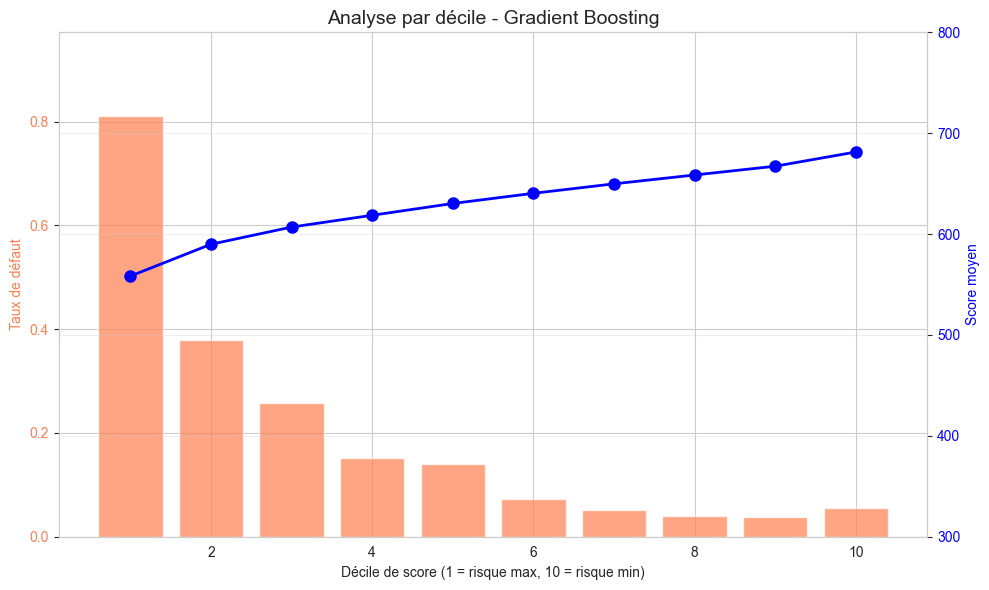

Graphique des déciles sauvegardé: analyse_deciles.png


In [58]:
# ============================================================================
# BLOC 13 - ANALYSE PAR DÉCILE (MEILLEUR MODÈLE)
# ============================================================================

y_proba_best = best_metrics['y_proba']

# Calcul des déciles
df_test = pd.DataFrame({
    'BAD': y_test,
    'prob': y_proba_best,
    'score': 600 - (20/np.log(2)) * np.log(y_proba_best/(1-y_proba_best))
})

df_test['decile'] = pd.qcut(df_test['score'], 10, labels=False) + 1
decile_stats = df_test.groupby('decile').agg({
    'BAD': ['count', 'sum', 'mean'],
    'score': ['min', 'max', 'mean']
}).round(4)

decile_stats.columns = ['N', 'N_defauts', 'Taux_defaut', 'Score_min', 'Score_max', 'Score_moyen']
decile_stats = decile_stats.reset_index()

print(f"\nSTATISTIQUES PAR DÉCILE - {best_model_name}:")
print("-" * 90)
print(f"{'Décile':<8} {'N':<8} {'Défauts':<10} {'Taux défaut':<15} {'Score min':<12} {'Score max':<12} {'Score moy':<12}")
print("-" * 90)
for _, row in decile_stats.iterrows():
    print(f"{int(row['decile']):<8} {int(row['N']):<8} {int(row['N_defauts']):<10} "
          f"{row['Taux_defaut']:.2%}        {row['Score_min']:<12.1f} {row['Score_max']:<12.1f} {row['Score_moyen']:<12.1f}")

# Visualisation des déciles
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(decile_stats['decile'], decile_stats['Taux_defaut'], 
        color='coral', alpha=0.7, label='Taux de défaut')
ax1.set_xlabel('Décile de score (1 = risque max, 10 = risque min)')
ax1.set_ylabel('Taux de défaut', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')
ax1.set_ylim(0, max(decile_stats['Taux_defaut'])*1.2)

ax2 = ax1.twinx()
ax2.plot(decile_stats['decile'], decile_stats['Score_moyen'], 
         'bo-', linewidth=2, markersize=8, label='Score moyen')
ax2.set_ylabel('Score moyen', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(300, 800)

plt.title(f'Analyse par décile - {best_model_name}', fontsize=14)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('analyse_deciles.png', dpi=150, bbox_inches='tight')

plt.show(block=False)
plt.pause(1)
print("Graphique des déciles sauvegardé: analyse_deciles.png")



12. DASHBOARD PLOTLY COMPLET


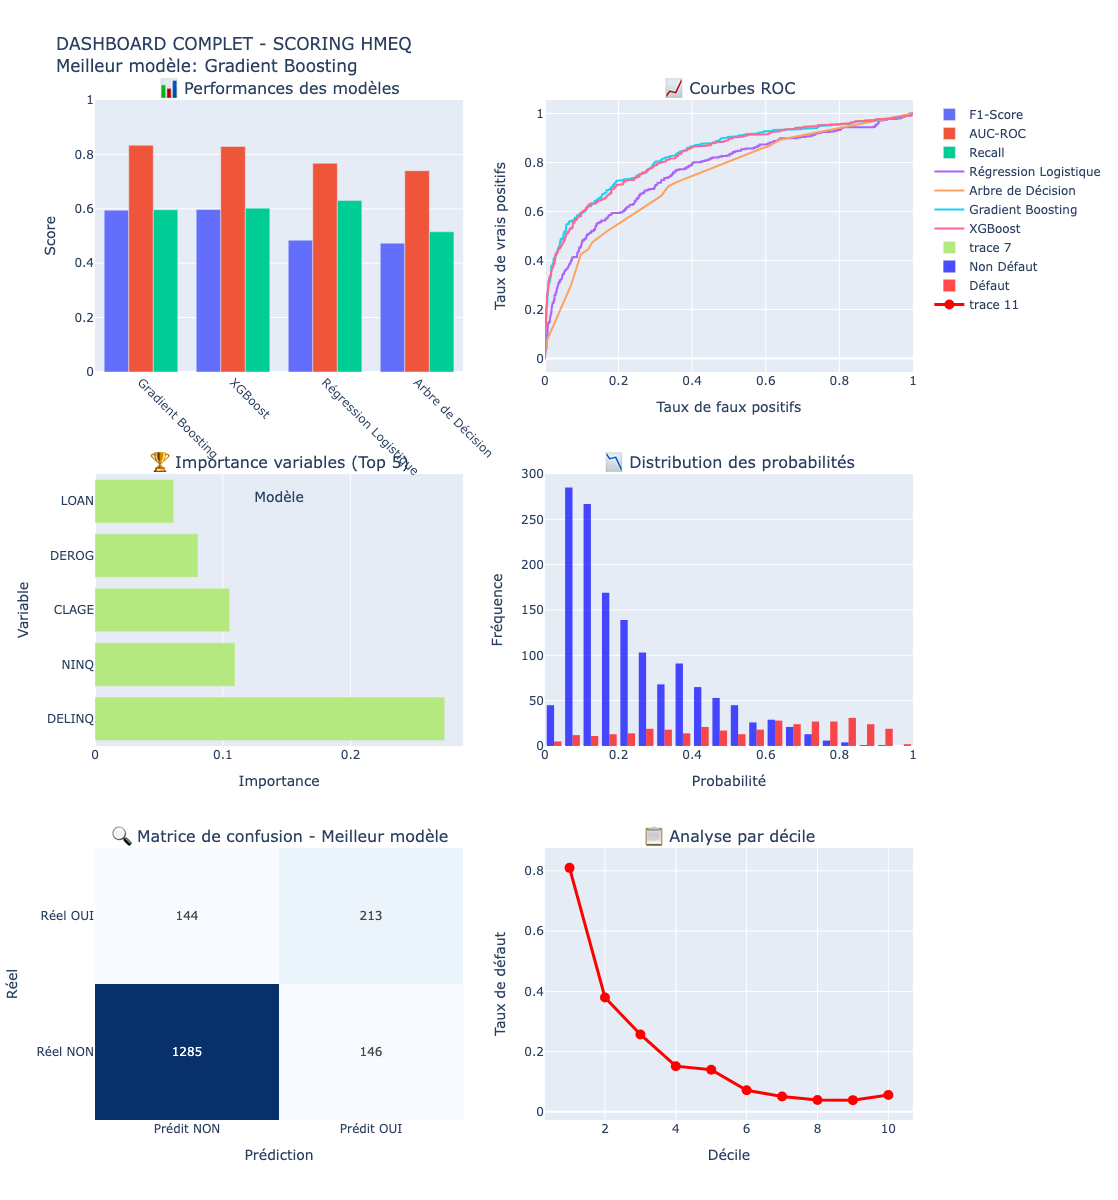

 Dashboard complet: dashboard_complet.html


In [62]:
print("\n12. DASHBOARD PLOTLY COMPLET")
print("=" * 60)

# Création du dashboard avec plusieurs graphiques
fig_dashboard = make_subplots(
    rows=3, cols=2,
    subplot_titles=('📊 Performances des modèles',
                    '📈 Courbes ROC',
                    '🏆 Importance variables (Top 5)',
                    '📉 Distribution des probabilités',
                    '🔍 Matrice de confusion - Meilleur modèle',
                    '📋 Analyse par décile'),
    specs=[[{'type': 'bar'}, {'type': 'scatter'}],
           [{'type': 'bar'}, {'type': 'histogram'}],
           [{'type': 'heatmap'}, {'type': 'scatter'}]],
    vertical_spacing=0.1,
    horizontal_spacing=0.1
)

# 1. Graphique des performances
for metric in ['F1-Score', 'AUC-ROC', 'Recall']:
    fig_dashboard.add_trace(
        go.Bar(name=metric, x=results_df['Modèle'], y=results_df[metric]),
        row=1, col=1
    )

# 2. Courbes ROC
for i, (name, res) in enumerate(list(results.items())[:4]):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    fig_dashboard.add_trace(
        go.Scatter(x=fpr, y=tpr, name=name, mode='lines'),
        row=1, col=2
    )

# 3. Importance variables (Top 5 du meilleur modèle)
if best_model_name in importances_dict:
    top5 = importances_dict[best_model_name].head(5)
    fig_dashboard.add_trace(
        go.Bar(x=top5['Importance' if 'Importance' in top5.columns else '|Coefficient|'],
               y=top5['Variable'],
               orientation='h'),
        row=2, col=1
    )

# 4. Distribution des probabilités
y_proba_best = best_metrics['y_proba']
fig_dashboard.add_trace(
    go.Histogram(x=y_proba_best[y_test == 0], name='Non Défaut', 
                 marker_color='blue', opacity=0.7),
    row=2, col=2
)
fig_dashboard.add_trace(
    go.Histogram(x=y_proba_best[y_test == 1], name='Défaut',
                 marker_color='red', opacity=0.7),
    row=2, col=2
)

# 5. Matrice de confusion du meilleur modèle
cm_best = best_metrics['confusion_matrix']
fig_dashboard.add_trace(
    go.Heatmap(z=cm_best,
               x=['Prédit NON', 'Prédit OUI'],
               y=['Réel NON', 'Réel OUI'],
               text=cm_best,
               texttemplate="%{text}",
               colorscale='Blues',
               showscale=False),
    row=3, col=1
)

# 6. Analyse par décile
df_test = pd.DataFrame({
    'BAD': y_test,
    'prob': y_proba_best,
    'score': 600 - (20/np.log(2)) * np.log(y_proba_best/(1-y_proba_best))
})
df_test['decile'] = pd.qcut(df_test['score'], 10, labels=False) + 1
decile_stats = df_test.groupby('decile')['BAD'].mean().reset_index()

fig_dashboard.add_trace(
    go.Scatter(x=decile_stats['decile'], y=decile_stats['BAD'],
               mode='lines+markers', line=dict(color='red', width=3),
               marker=dict(size=10)),
    row=3, col=2
)

# Mise en page du dashboard
fig_dashboard.update_layout(
    height=1200,
    width=1400,
    title_text=f"DASHBOARD COMPLET - SCORING HMEQ<br>Meilleur modèle: {best_model_name}",
    showlegend=True
)

fig_dashboard.update_xaxes(title_text="Modèle", row=1, col=1, tickangle=45)
fig_dashboard.update_yaxes(title_text="Score", row=1, col=1, range=[0, 1])
fig_dashboard.update_xaxes(title_text="Taux de faux positifs", row=1, col=2)
fig_dashboard.update_yaxes(title_text="Taux de vrais positifs", row=1, col=2)
fig_dashboard.update_xaxes(title_text="Importance", row=2, col=1)
fig_dashboard.update_yaxes(title_text="Variable", row=2, col=1)
fig_dashboard.update_xaxes(title_text="Probabilité", row=2, col=2)
fig_dashboard.update_yaxes(title_text="Fréquence", row=2, col=2)
fig_dashboard.update_xaxes(title_text="Prédiction", row=3, col=1)
fig_dashboard.update_yaxes(title_text="Réel", row=3, col=1)
fig_dashboard.update_xaxes(title_text="Décile", row=3, col=2)
fig_dashboard.update_yaxes(title_text="Taux de défaut", row=3, col=2)

fig_dashboard.show()
fig_dashboard.write_html('dashboard_complet.html')
print(" Dashboard complet: dashboard_complet.html")
